# PARAMETROS DE UN ARBOL DE DECISIÓN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
titanic_df = sns.load_dataset('titanic')
titanic_df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


# EDA

In [3]:
columns_to_drop = ['fare','embarked','class','who','adult_male','deck','embark_town','alive','alone']
titanic_df.drop(columns_to_drop,axis='columns',inplace=True)
titanic_df

,survived,pclass,sex,age,sibsp,parch
0,0,3,male,22.0,1,0
1,1,1,female,38.0,1,0
2,1,3,female,26.0,0,0
3,1,1,female,35.0,1,0
4,0,3,male,35.0,0,0
...,...,...,...,...,...,...
886,0,2,male,27.0,0,0
887,1,1,female,19.0,0,0
888,0,3,female,NaN,1,2
889,1,1,male,26.0,0,0


# ANALIZAMOS NULOS

In [4]:
titanic_df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0


In [5]:
titanic_df.dropna(inplace=True)

In [6]:
titanic_df

,survived,pclass,sex,age,sibsp,parch
0,0,3,male,22.0,1,0
1,1,1,female,38.0,1,0
2,1,3,female,26.0,0,0
3,1,1,female,35.0,1,0
4,0,3,male,35.0,0,0
...,...,...,...,...,...,...
885,0,3,female,39.0,0,5
886,0,2,male,27.0,0,0
887,1,1,female,19.0,0,0
889,1,1,male,26.0,0,0


# CODIFICACIÓN DE VARIABLES CATEGORICAS

In [7]:
titanic_df = pd.get_dummies(titanic_df,columns=['sex'],drop_first=True)
titanic_df.head()

,survived,pclass,age,sibsp,parch,sex_male
0,0,3,22.0,1,0,True
1,1,1,38.0,1,0,False
2,1,3,26.0,0,0,False
3,1,1,35.0,1,0,False
4,0,3,35.0,0,0,True


In [8]:
titanic_df['sex_male'] = titanic_df['sex_male'].astype(int)
titanic_df.rename(columns = {'sex_male':'sex'},inplace=True)
titanic_df.head(10)

,survived,pclass,age,sibsp,parch,sex
0,0,3,22.0,1,0,1
1,1,1,38.0,1,0,0
2,1,3,26.0,0,0,0
3,1,1,35.0,1,0,0
4,0,3,35.0,0,0,1
6,0,1,54.0,0,0,1
7,0,3,2.0,3,1,1
8,1,3,27.0,0,2,0
9,1,2,14.0,1,0,0
10,1,3,4.0,1,1,0


In [9]:
titanic_df.dtypes

,0
survived,int64
pclass,int64
age,float64
sibsp,int64
parch,int64
sex,int64


# ENTRENAMIENTO DE MODELO DE ARBOL DE DECISIÓN CON PARAMETROS

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = titanic_df.drop('survived',axis=1)
y = titanic_df['survived']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=00000)

## Entrenamiento sin parametros

In [11]:
tree1 = DecisionTreeClassifier()
tree1.fit(X_train,y_train)
y_pred = tree1.predict(X_test)
accuracy1 = accuracy_score(y_test,y_pred)
print(f"Accuracy Tree 1 : {accuracy1}")

Accuracy Tree 1 : 0.7692307692307693


## 1. Profundidad del árbol (max_depth)
Controla cuán profundo puede crecer el árbol. Un árbol muy profundo puede sobreajustarse a los datos de entrenamiento, mientras que un árbol muy poco profundo puede ser subajustado.

In [13]:
tree2 = DecisionTreeClassifier(max_depth=3)
tree2.fit(X_train,y_train)
y_pred = tree2.predict(X_test)
accuracy2 = accuracy_score(y_test,y_pred)
print(f"Accuracy Tree 2 : {accuracy2}")

Accuracy Tree 2 : 0.7832167832167832


# 2. Número mínimo de muestras por división (min_samples_split)
Determina el número mínimo de muestras que debe tener un nodo antes de dividirse. Un valor más alto reduce el sobreajuste.

In [14]:
tree3 = DecisionTreeClassifier(min_samples_split=10)
tree3.fit(X_train,y_train)
y_pred = tree3.predict(X_test)
accuracy3 = accuracy_score(y_test,y_pred)
print(f'Accuracy TREE 3 : {accuracy3}')

Accuracy TREE 3 : 0.7902097902097902


# 3. Número mínimo de muestras por hoja (min_samples_leaf)
Define el número mínimo de muestras que puede tener una hoja. Un valor más alto evita que el árbol aprenda patrones muy específicos (ruido).

In [15]:
tree4 = DecisionTreeClassifier(min_samples_leaf=4)
tree4.fit(X_train,y_train)
y_pred = tree4.predict(X_test)
accuracy4 = accuracy_score(y_test,y_pred)
print(f'Accuracy TREE 4 : {accuracy4}')

Accuracy TREE 4 : 0.7832167832167832


# 4. Criterio de división (criterion)
gini (por defecto): mide la impureza de Gini(es una medida utilizada en los árboles de decisión para evaluar la calidad de una partición de datos en los nodos).
entropy: usa la ganancia de información para las divisiones.

In [16]:
tree5 = DecisionTreeClassifier(criterion='entropy')
tree5.fit(X_train,y_train)
y_pred = tree5.predict(X_test)
accuracy5 = accuracy_score(y_test,y_pred)
print(f'Accuracy TREE 5 : {accuracy5}')

Accuracy TREE 5 : 0.7692307692307693


# COMPARANDO MODELOS

In [17]:
# Create a DataFrame
accuracies_data = {
    'Modelo': [
        'Tree 1 (Default)',
        'Tree 2 (max_depth=3)',
        'Tree 3 (min_samples_split=10)',
        'Tree 4 (min_samples_leaf=4)',
        'Tree 5 (criterion=entropy)'
    ],
    'Accuracy': [accuracy1, accuracy2, accuracy3, accuracy4, accuracy5]
}
accuracies_df = pd.DataFrame(accuracies_data)
print("DataFrame con las precisiones de cada modelo:")
accuracies_df

DataFrame con las precisiones de cada modelo:


,Modelo,Accuracy
0,Tree 1 (Default),0.769231
1,Tree 2 (max_depth=3),0.783217
2,Tree 3 (min_samples_split=10),0.790210
3,Tree 4 (min_samples_leaf=4),0.783217
4,Tree 5 (criterion=entropy),0.769231


/tmp/ipython-input-1294974637.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo',y='Accuracy',data=accuracies_df,palette='bright',saturation= 2.0,edgecolor='black',linewidth=2)


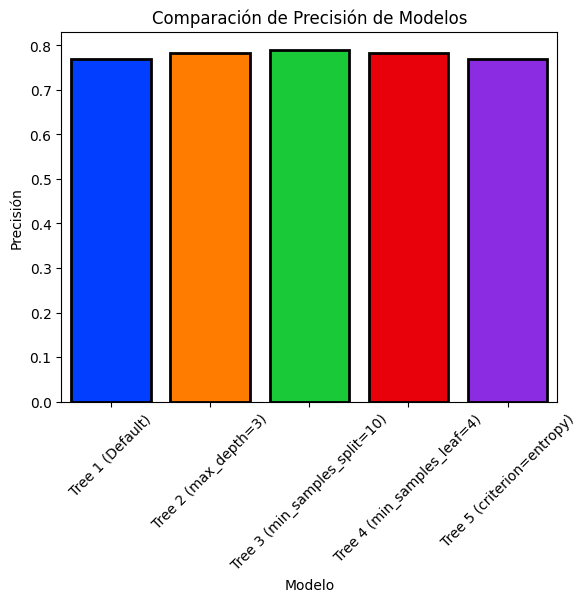

In [18]:
sns.barplot(x='Modelo',y='Accuracy',data=accuracies_df,palette='bright',saturation= 2.0,edgecolor='black',linewidth=2)
plt.title('Comparación de Precisión de Modelos')
plt.xlabel('Modelo')
plt.ylabel('Precisión')
plt.xticks(rotation=45)
plt.show()